# Glucose Cluster Prediction — Machine Learning Models

This notebook trains and evaluates Random Forest and Neural Network models to predict glucose cluster membership from sleep and physiological features collected by the Fitbit Sense wearable.

## Objective

Predict whether an observation belongs to the high or low glucose cluster using sleep stages, HRV, respiratory rate, oxygen saturation, restlessness, and temperature-related measurements.

## Input Features

- Raw sleep and physiological variables
- Nightly temperature and baseline-relative nightly temperature variability

## Models

- **Random Forest** — trained on raw features
- **Neural Network (MLP)** — two hidden layers (32, 16 units), trained on features standardized using training data only

## Evaluation

- Participant-level five-fold cross-validation
- Accuracy, precision, recall, F1, and ROC AUC
- Out-of-fold ROC curves and confusion matrices

## Interpretability

- Random Forest feature importance and SHAP plots explore which measurements contribute to its predictions

## Key Finding

The Random Forest showed variable performance across folds (mean ROC AUC = 0.699; out-of-fold ROC AUC = 0.598). The Neural Network performed poorly (out-of-fold ROC AUC = 0.421). These results do not support a claim of strong or reliable prediction of glucose clusters from the available measurements.

GLUCOSE PHENOTYPE — PARTICIPANT-LEVEL 5-FOLD CV
Observations:  144
Participants: 44
Predictors:   17
Classes:     {0: 81, 1: 63}

RANDOM FOREST — RESULTS BY FOLD
 fold  accuracy  precision  recall    f1  roc_auc
    1     0.643      1.000   0.286 0.444    0.898
    2     0.500      0.333   0.333 0.333    0.556
    3     0.741      0.636   0.700 0.667    0.753
    4     0.704      0.538   0.778 0.636    0.796
    5     0.500      0.571   0.286 0.381    0.493

NEURAL NETWORK — RESULTS BY FOLD
 fold  accuracy  precision  recall    f1  roc_auc
    1     0.500      0.500   0.286 0.364    0.551
    2     0.542      0.000   0.000 0.000    0.563
    3     0.333      0.346   0.900 0.500    0.353
    4     0.296      0.273   0.667 0.387    0.364
    5     0.519      0.545   0.643 0.590    0.409

FINAL 5-FOLD CROSS-VALIDATION PERFORMANCE

RANDOM FOREST
ACCURACY  : 0.617 ± 0.113
PRECISION : 0.616 ± 0.243
RECALL    : 0.477 ± 0.242
F1        : 0.492 ± 0.151
ROC_AUC   : 0.699 ± 0.170

NEURAL NETWORK


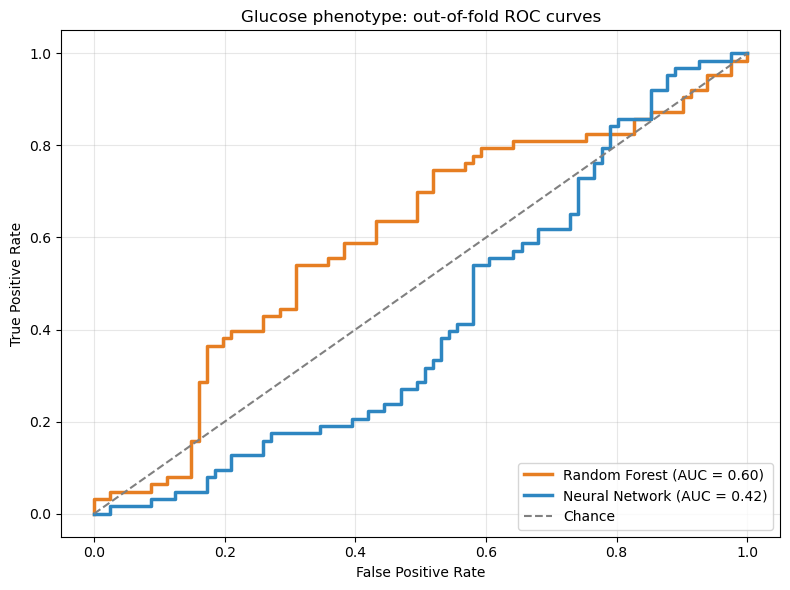

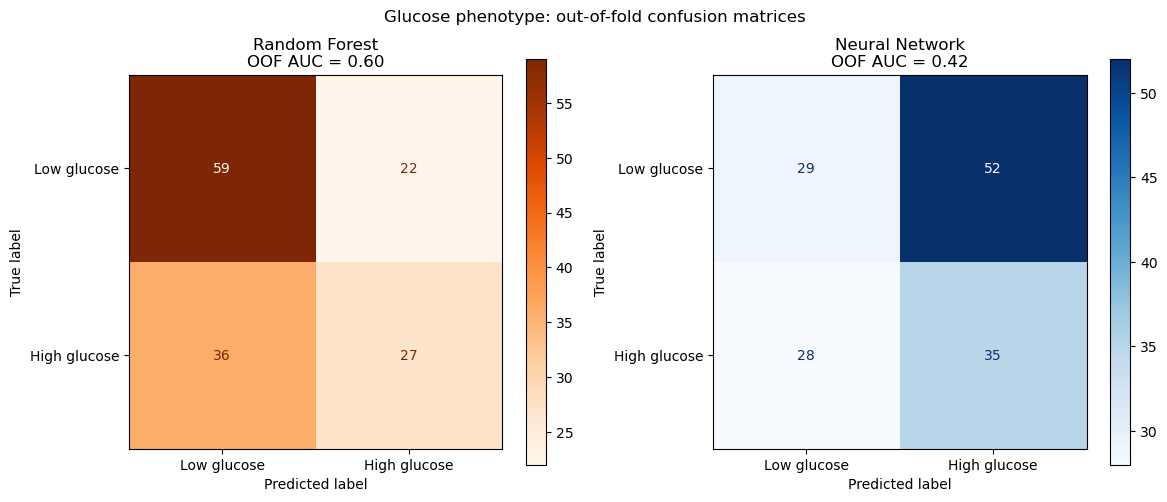

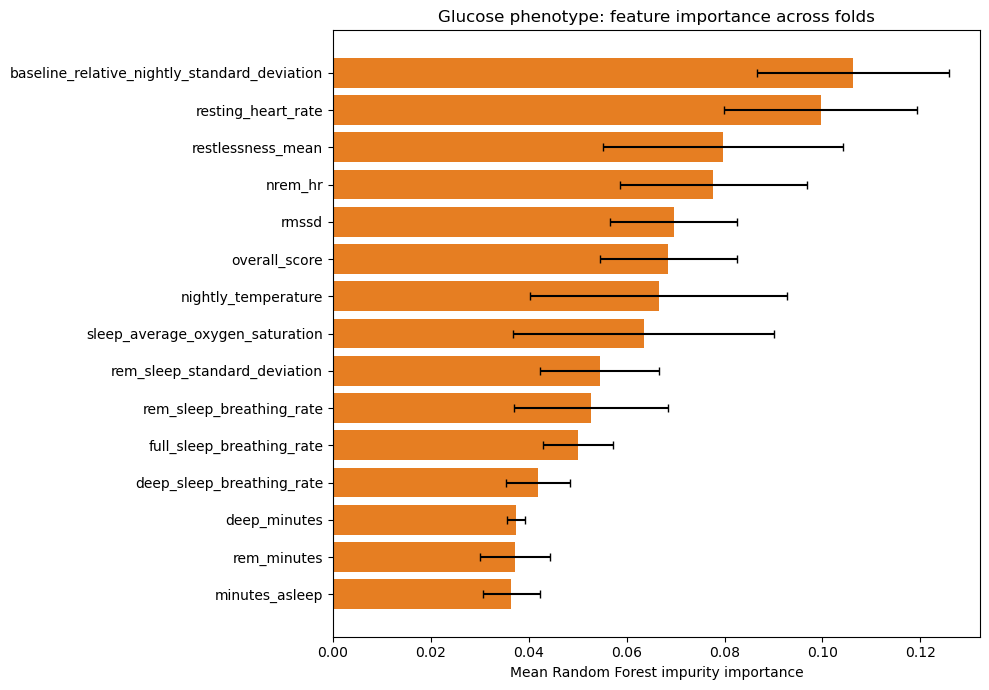

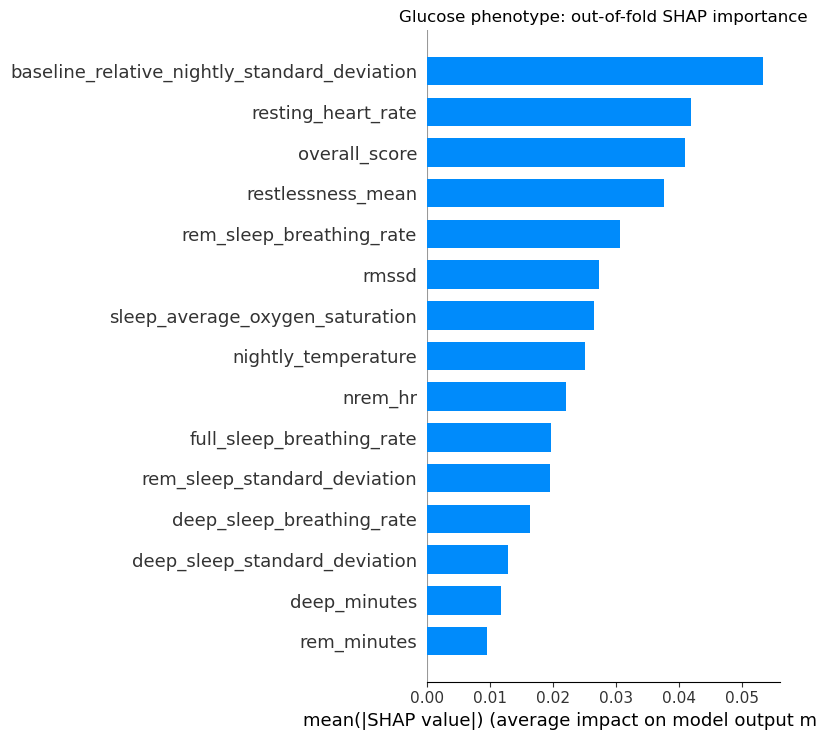

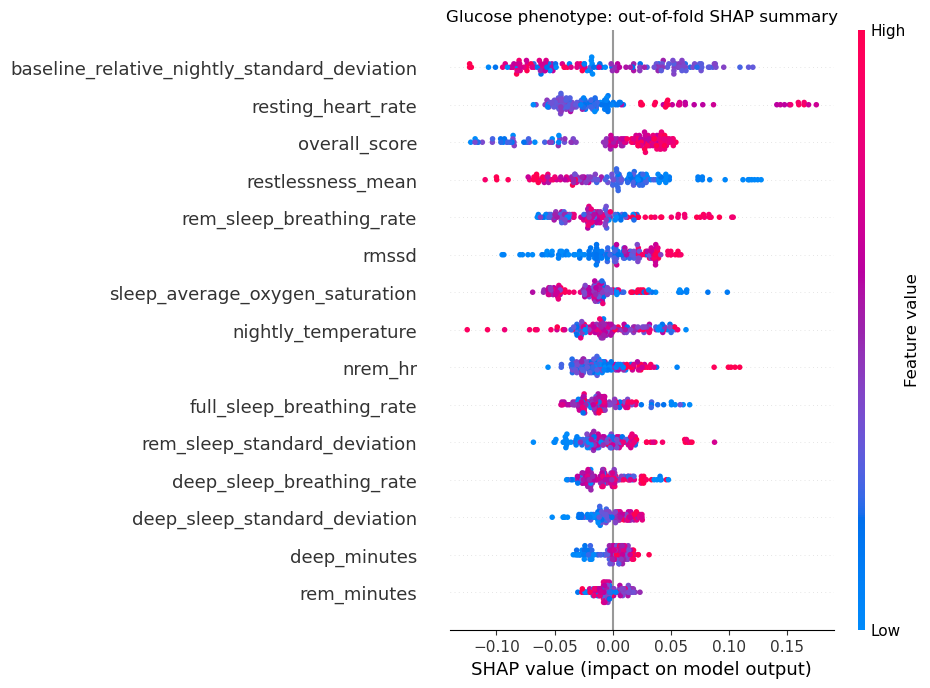


Five figures displayed and results saved in figures/


In [12]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# CONFIGURATION

DATA_PATH = "data/glucose_cluster_cleaned_no_duplicates.xlsx"
SHEET_NAME = "Cleaned_Data"

TARGET_COL = "glucose_cluster"
ID_COL = "participant_id"
DATE_COL = "date"
STUDY_DAY_COL = "study_day"

N_SPLITS = 5
RANDOM_STATE = 42

FIGURE_DIR = "figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

COLOR_RF = "#E67E22"
COLOR_NN = "#2E86C1"

FEATURE_COLS = [
    "rem_minutes",
    "deep_minutes",
    "overall_score",
    "restlessness_mean",
    "minutes_asleep",
    "deep_sleep_breathing_rate",
    "rem_sleep_breathing_rate",
    "full_sleep_breathing_rate",
    "full_sleep_standard_deviation",
    "deep_sleep_standard_deviation",
    "rem_sleep_standard_deviation",
    "sleep_average_oxygen_saturation",
    "rmssd",
    "nrem_hr",
    "resting_heart_rate",
    "nightly_temperature",
    "baseline_relative_nightly_standard_deviation",
]

METRICS = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
]

# LOAD AND CHECK DATA


df = pd.read_excel(
    DATA_PATH,
    sheet_name=SHEET_NAME,
)

required_cols = FEATURE_COLS + [
    TARGET_COL,
    ID_COL,
    DATE_COL,
    STUDY_DAY_COL,
]

missing_cols = [
    col for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        "Missing columns: " + ", ".join(missing_cols)
    )

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="raise",
).dt.normalize()

missing_values = df[required_cols].isna().sum()
missing_values = missing_values[missing_values > 0]

if not missing_values.empty:
    print(missing_values)
    raise ValueError(
        "Missing values found in required columns."
    )

if not set(df[TARGET_COL].unique()).issubset({0, 1}):
    raise ValueError(
        f"{TARGET_COL} must contain only 0 and 1."
    )

if df[TARGET_COL].nunique() != 2:
    raise ValueError(
        f"{TARGET_COL} must contain both classes."
    )


duplicates = df.duplicated(
    subset=[
        ID_COL,
        STUDY_DAY_COL,
        DATE_COL,
    ],
    keep=False,
)

if duplicates.any():
    print(
        df.loc[
            duplicates,
            [
                ID_COL,
                STUDY_DAY_COL,
                DATE_COL,
                TARGET_COL,
            ],
        ]
        .sort_values(
            [ID_COL, DATE_COL, STUDY_DAY_COL]
        )
        .to_string(index=False)
    )

    raise ValueError(
        "Duplicate participant/study_day/date "
        "observations found."
    )

if any(col.endswith("_norm") for col in FEATURE_COLS):
    raise ValueError(
        "Precomputed normalized predictors selected."
    )

if "aligned_cluster_label" in FEATURE_COLS:
    raise ValueError(
        "Wrist temperature cluster selected as a predictor."
    )

df = df.reset_index(drop=True)

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].astype(int).copy()
groups = df[ID_COL].copy()

print("=" * 70)
print("GLUCOSE PHENOTYPE — PARTICIPANT-LEVEL 5-FOLD CV")
print("=" * 70)
print(f"Observations:  {len(df)}")
print(f"Participants: {groups.nunique()}")
print(f"Predictors:   {len(FEATURE_COLS)}")
print(
    "Classes:     "
    f"{y.value_counts().sort_index().to_dict()}"
)

# PREPARE PARTICIPANT-LEVEL FOLDS

cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)


folds = list(
    cv.split(
        X,
        y,
        groups=groups,
    )
)

rf_fold_results = []
nn_fold_results = []
rf_importances = []
fold_assignments = []

oof_rf_pred = np.zeros(len(df), dtype=int)
oof_rf_proba = np.zeros(len(df), dtype=float)

oof_nn_pred = np.zeros(len(df), dtype=int)
oof_nn_proba = np.zeros(len(df), dtype=float)


shap_oof = np.full(
    (len(df), len(FEATURE_COLS)),
    np.nan,
)

# HELPER FUNCTIONS

def calculate_metrics(y_true, y_pred, y_proba):
    """Calculate performance for class 1."""

    metrics = {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "roc_auc": np.nan,
    }

    if y_true.nunique() == 2:
        metrics["roc_auc"] = roc_auc_score(
            y_true,
            y_proba,
        )

    return metrics


def extract_class1_shap(explainer, X_test):
    """Support common SHAP versions."""

    values = explainer.shap_values(X_test)

    if isinstance(values, list):
        values = values[1]

    elif (
        isinstance(values, np.ndarray)
        and values.ndim == 3
    ):
        values = values[:, :, 1]

    values = np.asarray(values)

    if values.shape != X_test.shape:
        raise ValueError(
            f"Unexpected SHAP shape: {values.shape}; "
            f"expected {X_test.shape}."
        )

    return values


# FIVE-FOLD CROSS-VALIDATION


for fold_number, (train_idx, test_idx) in enumerate(
    folds,
    start=1,
):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    train_participants = set(
        groups.iloc[train_idx]
    )

    test_participants = set(
        groups.iloc[test_idx]
    )

    if train_participants & test_participants:
        raise ValueError(
            f"Participant overlap in fold {fold_number}."
        )

    if y_train.nunique() != 2:
        raise ValueError(
            f"Training fold {fold_number} has "
            "only one class."
        )

    for row_index in test_idx:
        fold_assignments.append({
            "row_index": int(row_index),
            ID_COL: df.loc[row_index, ID_COL],
            DATE_COL: df.loc[row_index, DATE_COL],
            STUDY_DAY_COL: df.loc[
                row_index,
                STUDY_DAY_COL,
            ],
            TARGET_COL: int(y.loc[row_index]),
            "fold": fold_number,
        })

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    )

    X_test_scaled = scaler.transform(
        X_test
    )

    # RANDOM FOREST

    rf = RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE + fold_number,
        n_jobs=-1,
    )

    rf.fit(
        X_train,
        y_train,
    )

    rf_pred = rf.predict(
        X_test
    )

    rf_class1_index = list(
        rf.classes_
    ).index(1)

    rf_proba = rf.predict_proba(
        X_test
    )[:, rf_class1_index]

    oof_rf_pred[test_idx] = rf_pred
    oof_rf_proba[test_idx] = rf_proba

    rf_metrics = calculate_metrics(
        y_test,
        rf_pred,
        rf_proba,
    )

    rf_fold_results.append({
        "fold": fold_number,
        **rf_metrics,
    })

    rf_importances.append(
        pd.DataFrame({
            "feature": FEATURE_COLS,
            "importance": rf.feature_importances_,
            "fold": fold_number,
        })
    )

    explainer = shap.TreeExplainer(rf)

    shap_oof[test_idx, :] = extract_class1_shap(
        explainer,
        X_test,
    )

    # NEURAL NETWORK

    nn = MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.20,
        random_state=RANDOM_STATE + fold_number,
    )

    nn.fit(
        X_train_scaled,
        y_train,
    )

    nn_pred = nn.predict(
        X_test_scaled
    )

    nn_class1_index = list(
        nn.classes_
    ).index(1)

    nn_proba = nn.predict_proba(
        X_test_scaled
    )[:, nn_class1_index]

    oof_nn_pred[test_idx] = nn_pred
    oof_nn_proba[test_idx] = nn_proba

    nn_metrics = calculate_metrics(
        y_test,
        nn_pred,
        nn_proba,
    )

    nn_fold_results.append({
        "fold": fold_number,
        **nn_metrics,
    })

if np.isnan(shap_oof).any():
    raise ValueError(
        "Some observations did not receive SHAP values."
    )

rf_results = pd.DataFrame(rf_fold_results)
nn_results = pd.DataFrame(nn_fold_results)

# RESULTS BY FOLD

print("\n" + "=" * 70)
print("RANDOM FOREST — RESULTS BY FOLD")
print("=" * 70)

print(
    rf_results[
        ["fold"] + METRICS
    ]
    .round(3)
    .to_string(index=False)
)

print("\n" + "=" * 70)
print("NEURAL NETWORK — RESULTS BY FOLD")
print("=" * 70)

print(
    nn_results[
        ["fold"] + METRICS
    ]
    .round(3)
    .to_string(index=False)
)

# MEAN ± SD ACROSS FOLDS

print("\n" + "=" * 70)
print("FINAL 5-FOLD CROSS-VALIDATION PERFORMANCE")
print("=" * 70)

for model_name, results in [
    ("RANDOM FOREST", rf_results),
    ("NEURAL NETWORK", nn_results),
]:
    print(f"\n{model_name}")

    for metric in METRICS:
        mean_value = results[metric].mean()
        sd_value = results[metric].std(ddof=1)

        print(
            f"{metric.upper():10s}: "
            f"{mean_value:.3f} ± {sd_value:.3f}"
        )

# OVERALL OUT-OF-FOLD PERFORMANCE

print("\n" + "=" * 70)
print("OUT-OF-FOLD PERFORMANCE")
print("=" * 70)

for model_name, predictions, probabilities in [
    (
        "Random Forest",
        oof_rf_pred,
        oof_rf_proba,
    ),
    (
        "Neural Network",
        oof_nn_pred,
        oof_nn_proba,
    ),
]:
    print(f"\n{model_name}")

    print(
        f"Accuracy:  "
        f"{accuracy_score(y, predictions):.3f}"
    )

    print(
        f"Precision: "
        f"{precision_score(y, predictions, zero_division=0):.3f}"
    )

    print(
        f"Recall:    "
        f"{recall_score(y, predictions, zero_division=0):.3f}"
    )

    print(
        f"F1:        "
        f"{f1_score(y, predictions, zero_division=0):.3f}"
    )

    print(
        f"ROC-AUC:   "
        f"{roc_auc_score(y, probabilities):.3f}"
    )

# OUT-OF-FOLD CLASSIFICATION REPORTS

print("\n" + "=" * 70)
print("RANDOM FOREST — OOF CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y,
        oof_rf_pred,
        labels=[0, 1],
        target_names=[
            "Low glucose cluster",
            "High glucose cluster",
        ],
        digits=3,
        zero_division=0,
    )
)

print("\n" + "=" * 70)
print("NEURAL NETWORK — OOF CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y,
        oof_nn_pred,
        labels=[0, 1],
        target_names=[
            "Low glucose cluster",
            "High glucose cluster",
        ],
        digits=3,
        zero_division=0,
    )
)

# FIGURE 1: OUT-OF-FOLD ROC CURVES

rf_oof_auc = roc_auc_score(
    y,
    oof_rf_proba,
)

nn_oof_auc = roc_auc_score(
    y,
    oof_nn_proba,
)

fpr_rf, tpr_rf, _ = roc_curve(
    y,
    oof_rf_proba,
)

fpr_nn, tpr_nn, _ = roc_curve(
    y,
    oof_nn_proba,
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.plot(
    fpr_rf,
    tpr_rf,
    color=COLOR_RF,
    linewidth=2.5,
    label=f"Random Forest (AUC = {rf_oof_auc:.2f})",
)

ax.plot(
    fpr_nn,
    tpr_nn,
    color=COLOR_NN,
    linewidth=2.5,
    label=f"Neural Network (AUC = {nn_oof_auc:.2f})",
)

ax.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    label="Chance",
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.set_title(
    "Glucose phenotype: out-of-fold ROC curves"
)

ax.legend(
    loc="lower right"
)

ax.grid(
    alpha=0.3
)

fig.tight_layout()

fig.savefig(
    os.path.join(
        FIGURE_DIR,
        "glucose_cv_roc_curve.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# FIGURE 2: OUT-OF-FOLD CONFUSION MATRICES

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
)

ConfusionMatrixDisplay.from_predictions(
    y,
    oof_rf_pred,
    labels=[0, 1],
    display_labels=[
        "Low glucose",
        "High glucose",
    ],
    cmap="Oranges",
    ax=axes[0],
)

axes[0].set_title(
    "Random Forest\n"
    f"OOF AUC = {rf_oof_auc:.2f}"
)

axes[0].grid(False)

ConfusionMatrixDisplay.from_predictions(
    y,
    oof_nn_pred,
    labels=[0, 1],
    display_labels=[
        "Low glucose",
        "High glucose",
    ],
    cmap="Blues",
    ax=axes[1],
)

axes[1].set_title(
    "Neural Network\n"
    f"OOF AUC = {nn_oof_auc:.2f}"
)

axes[1].grid(False)

fig.suptitle(
    "Glucose phenotype: out-of-fold confusion matrices"
)

fig.tight_layout()

fig.savefig(
    os.path.join(
        FIGURE_DIR,
        "glucose_cv_confusion_matrices.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# FIGURE 3: RF FEATURE IMPORTANCE ACROSS FOLDS

importance_summary = (
    pd.concat(
        rf_importances,
        ignore_index=True,
    )
    .groupby("feature")["importance"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values(
        "mean",
        ascending=False,
    )
)

plot_importance = (
    importance_summary
    .head(15)
    .sort_values("mean")
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

ax.barh(
    plot_importance["feature"],
    plot_importance["mean"],
    xerr=plot_importance["std"],
    capsize=3,
    color=COLOR_RF,
)

ax.set_xlabel(
    "Mean Random Forest impurity importance"
)

ax.set_title(
    "Glucose phenotype: feature importance across folds"
)

fig.tight_layout()

fig.savefig(
    os.path.join(
        FIGURE_DIR,
        "glucose_cv_rf_feature_importance.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# FIGURE 4: OUT-OF-FOLD SHAP BAR PLOT

shap.summary_plot(
    shap_oof,
    X,
    plot_type="bar",
    max_display=15,
    show=False,
)

plt.title(
    "Glucose phenotype: out-of-fold SHAP importance"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "glucose_cv_shap_importance.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# FIGURE 5: OUT-OF-FOLD SHAP BEESWARM

shap.summary_plot(
    shap_oof,
    X,
    max_display=15,
    show=False,
)

plt.title(
    "Glucose phenotype: out-of-fold SHAP summary"
)

plt.subplots_adjust(
    left=0.35,
    right=0.95,
    top=0.90,
    bottom=0.10,
)

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "glucose_cv_shap_beeswarm.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# SAVE TABLES AND DATE-IDENTIFIED PREDICTIONS

rf_results.to_csv(
    os.path.join(
        FIGURE_DIR,
        "glucose_cv_rf_fold_results.csv",
    ),
    index=False,
)

nn_results.to_csv(
    os.path.join(
        FIGURE_DIR,
        "glucose_cv_nn_fold_results.csv",
    ),
    index=False,
)

importance_summary.to_csv(
    os.path.join(
        FIGURE_DIR,
        "glucose_cv_rf_feature_importance.csv",
    ),
    index=False,
)

fold_assignments_df = (
    pd.DataFrame(fold_assignments)
    .sort_values("row_index")
)

fold_assignments_df.to_csv(
    os.path.join(
        FIGURE_DIR,
        "glucose_cv_fold_assignments.csv",
    ),
    index=False,
)

oof_predictions = df[
    [
        ID_COL,
        STUDY_DAY_COL,
        DATE_COL,
        TARGET_COL,
    ]
].copy()

oof_predictions["rf_prediction"] = oof_rf_pred
oof_predictions["rf_probability"] = oof_rf_proba

oof_predictions["nn_prediction"] = oof_nn_pred
oof_predictions["nn_probability"] = oof_nn_proba

oof_predictions.to_csv(
    os.path.join(
        FIGURE_DIR,
        "glucose_cv_oof_predictions.csv",
    ),
    index=False,
)

summary_rows = []

for model_name, results, predictions, probabilities in [
    (
        "Random Forest",
        rf_results,
        oof_rf_pred,
        oof_rf_proba,
    ),
    (
        "Neural Network",
        nn_results,
        oof_nn_pred,
        oof_nn_proba,
    ),
]:
    row = {
        "Model": model_name,
    }

    for metric in METRICS:
        row[f"{metric}_mean"] = (
            results[metric].mean()
        )

        row[f"{metric}_SD"] = (
            results[metric].std(ddof=1)
        )

    row["OOF_Accuracy"] = accuracy_score(
        y,
        predictions,
    )

    row["OOF_Precision"] = precision_score(
        y,
        predictions,
        zero_division=0,
    )

    row["OOF_Recall"] = recall_score(
        y,
        predictions,
        zero_division=0,
    )

    row["OOF_F1"] = f1_score(
        y,
        predictions,
        zero_division=0,
    )

    row["OOF_ROC_AUC"] = roc_auc_score(
        y,
        probabilities,
    )

    summary_rows.append(row)

pd.DataFrame(summary_rows).to_csv(
    os.path.join(
        FIGURE_DIR,
        "glucose_cv_summary.csv",
    ),
    index=False,
)

print(
    f"\nFive figures displayed and results saved "
    f"in {FIGURE_DIR}/"
)